In [84]:
# # Description
# 
# Prove that the Noise Reduction model works on a 2D polinomial.

# Add libs folder path to system variables to make the importation of local libraries easier.
# __________________________________________________________________________________________________
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [85]:
def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6

In [86]:
data = np.arange(-5, 5, 0.001)
data_df = pd.DataFrame(data, columns=['x'])
data_df['y'] = polinomial_function(data_df['x'].values)

scaler = MinMaxScaler()
data_df = pd.DataFrame(scaler.fit_transform(data_df), columns=['x', 'y'])

In [87]:
data_df.shape

(10000, 2)

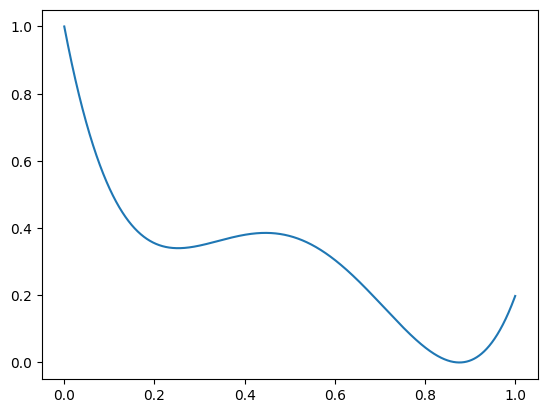

In [88]:
plt.plot(data_df['x'], data_df['y'])

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    data_df['x'].values, data_df['y'].values, test_size=0.2, random_state=42
)

# No noise XAI Benchmarck

In [90]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto'},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [91]:
# xai_benchmark.fit(data_df[['x']], data_df['y'].values)
xai_benchmark.fit(X_train.reshape(-1,1), y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [92]:
# xai_benchmark.predict(data_df[['x']], data_df['y'].values, get_metrics=True)
xai_benchmark.predict(X_test.reshape(-1,1), y_test, get_metrics=True)

({'ridge': array([0.22465081, 0.32179101, 0.50473425, ..., 0.1254662 , 0.54413551,
         0.18270953]),
  'pls': array([0.22453561, 0.32182142, 0.50503889, ..., 0.12520233, 0.54449921,
         0.18253147]),
  'decision_tree': array([0.27459417, 0.36268029, 0.36268029, ..., 0.07121389, 0.50534442,
         0.17907027]),
  'svm': array([0.21700239, 0.30964777, 0.48412598, ..., 0.12240719, 0.52170408,
         0.1770018 ]),
  'knn': array([0.27668958, 0.38415741, 0.37786457, ..., 0.0613229 , 0.49239231,
         0.18683249])},
 {'ridge': {'mse': 0.009103749158802096,
   'rmse': 0.09541356904970119,
   'mae': 0.0753578108524792,
   'R2': 0.7875035539572921},
  'pls': {'mse': 0.009101082255768953,
   'rmse': 0.09539959253460652,
   'mae': 0.07535820834646066,
   'R2': 0.7875658038508907},
  'decision_tree': {'mse': 0.00019886954104437291,
   'rmse': 0.014102111226492752,
   'mae': 0.011908406140477891,
   'R2': 0.9953580585360028},
  'svm': {'mse': 0.009378478703395296,
   'rmse': 0.0968

Add goussian noise to the dataframe

In [93]:
sigma = 0.05
df_noisy = add_gaussian_noise(
        df=data_df.copy(),
        columns=[x for x in data_df.columns],
        mean=0,
        std=sigma
)

In [94]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    df_noisy['x'].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

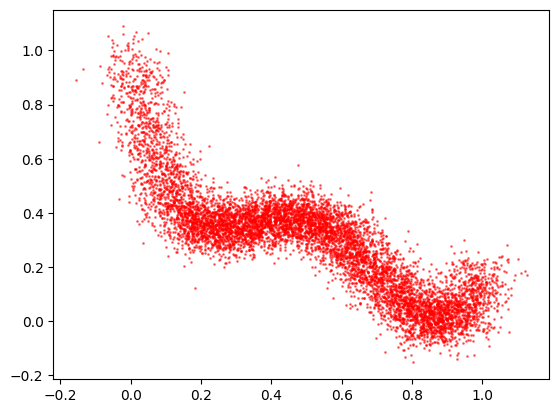

In [95]:
plt.scatter(X_train_noisy, y_train_noisy, s=1, c='r', alpha=0.5)

# Noisy XAI Benchmarck

In [96]:
xai_benchmark.fit(X_train_noisy.reshape(-1,1), y_train_noisy)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [97]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test_noisy, get_metrics=True)

({'ridge': array([0.21548909, 0.31808694, 0.46955992, ..., 0.14807847, 0.48935607,
         0.1418121 ]),
  'pls': array([0.21536412, 0.31811102, 0.46980407, ..., 0.14785556, 0.48962898,
         0.14158008]),
  'decision_tree': array([0.23843241, 0.36389276, 0.36389276, ..., 0.07847154, 0.36389276,
         0.07847154]),
  'svm': array([0.21161821, 0.30794302, 0.45015463, ..., 0.14832921, 0.46874039,
         0.14244598]),
  'knn': array([0.19240975, 0.34735209, 0.33116417, ..., 0.10559608, 0.35391874,
         0.09078498])},
 {'ridge': {'mse': 0.012643001837996572,
   'rmse': 0.11244110386329624,
   'mae': 0.08672145382571213,
   'R2': 0.7183490674611878},
  'pls': {'mse': 0.012641519834655836,
   'rmse': 0.11243451353857425,
   'mae': 0.08673263426050644,
   'R2': 0.7183820823755485},
  'decision_tree': {'mse': 0.007994998578438623,
   'rmse': 0.08941475593233268,
   'mae': 0.06497348878455994,
   'R2': 0.8218936583164699},
  'svm': {'mse': 0.012938013494736137,
   'rmse': 0.1137453

Create Datasets for DataLoaders

In [103]:
train_dataset = TensorDataset(
    X_train_noisy.reshape(-1,1),
    y_train_noisy.reshape(-1,1)
)
test_dataset = TensorDataset(
    X_test_noisy.reshape(-1,1),
    y_test_noisy.reshape(-1,1)
)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [104]:
denoiser = DenoisingAutoencoder(
    input_dim=1,
    latent_dim=32,
).to(device)

# denoiser_v2 = DenoisingAutoencoder_v2(
#     input_dim=1,
#     hidden_dims=[256, 128, 64, 32],
#     encoding_dim=8
# ).to(device)

# n_layers = 3
# hidden_layers = [(1, 64), (64, 32), (32, 1)]
# dropout_layers = [0.1, 0.2, 0.0]
# activation_func_layers = [nn.ReLU(), nn.ReLU(), nn.Identity()]
# want_dropout = [False, True, False]
# want_linear = [True, True, True]
# want_activation = [True, True, False]

# dense_nn = GridFullyDenseNN(
#     n_layers, hidden_layers, dropout_layers, activation_func_layers,
#     want_dropout, want_linear, want_activation
# ).to(device)

In [105]:
# Set model parameters and create the model Trainer object
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(denoiser.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=denoiser,
    train_generator=train_loader,
    val_generator=test_loader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=1000,
    checkpoints_path=os.path.join(
        CHECKPOINT_PATH, f'denoising_autoencoder_sigma{sigma}'
    ),
)

In [106]:
# denoiser = torch.load(os.path.join(CHECKPOINT_PATH, 'denoising_autoencoder.pth'))

In [107]:
# Train the model
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   0%|                                        | 0/1000 [00:00<?, ?epoch/s]

Epochs loop:   4%| | 39/1000 [01:45<43:22,  2.71s/epoch, Train loss: 0.007047067694365

Training stopped as validation loss did not improve for 15 epochs.


In [110]:
y_pred_test = model(torch.tensor(X_test.reshape(-1,1)).float().to(device)).cpu().detach().numpy()

In [111]:
# Show the metrics
gt_values = y_test
predicted_values = y_pred_test

mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
# mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
nn_benchmark = {
    'nn': {
        "MSE: ": mse,
        "RMSE: ": rmse,
        "MAE: ": mae,
        # "MAPE: ": mape,
        "R2: ": r_squared
    }
}
nn_benchmark

{'nn': {'MSE: ': 0.0012482568382259506,
  'RMSE: ': 0.03533067842861145,
  'MAE: ': 0.02032990808134696,
  'R2: ': 0.9708636368110977}}

# Denoise the entire noisy dataframe

In [115]:
complete_dataset = TensorDataset(df_noisy['x'].values.reshape(-1,1), df_noisy['y'].values.reshape(-1,1))
complete_dataloader = DataLoader(complete_dataset, batch_size=batch_size, shuffle=False)
y_denoised = trainer_basic.eval_dataloader(complete_dataloader)
y_denoised = torch.cat(y_denoised).view(-1)
len(y_denoised)

10000

In [116]:
df_denoised = pd.DataFrame({'x': df_noisy['x'], 'y': y_denoised.cpu().detach().numpy()})

In [117]:
X_train_denoised, X_test_denoised, y_train_denoised, y_test_denoised = train_test_split(
    df_denoised['x'].values, df_denoised['y'].values, test_size=0.2, random_state=42
)

In [118]:
xai_benchmark.fit(X_train_denoised.reshape(-1,1), y_train_denoised)
xai_benchmark.predict(X_test_denoised.reshape(-1,1), y_test_denoised, get_metrics=True)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


({'ridge': array([0.21809906, 0.32282333, 0.47743571, ..., 0.14929131, 0.49764214,
         0.14289506]),
  'pls': array([0.2179715 , 0.32284792, 0.47768492, ..., 0.14906377, 0.49792071,
         0.14265824]),
  'decision_tree': array([0.25279127, 0.36270807, 0.36270807, ..., 0.10021547, 0.38865791,
         0.0874313 ]),
  'svm': array([0.2176839 , 0.32081917, 0.47308559, ..., 0.14992017, 0.49298543,
         0.14362098]),
  'knn': array([0.25414014, 0.3724557 , 0.35844374, ..., 0.10283275, 0.37632805,
         0.08914278], dtype=float32)},
 {'ridge': {'mse': 0.005527864864647954,
   'rmse': 0.07434961240415416,
   'mae': 0.06139135179848446,
   'R2': 0.8574834481359987},
  'pls': {'mse': 0.005526832122898371,
   'rmse': 0.07434266690735793,
   'mae': 0.06138965383872276,
   'R2': 0.8575100737494535},
  'decision_tree': {'mse': 9.138397923193132e-05,
   'rmse': 0.009559496808510964,
   'mae': 0.007808099574001012,
   'R2': 0.9976439855288366},
  'svm': {'mse': 0.005546999414822438,
  

In [119]:
xai_benchmark.predict(data_df[['x']], data_df[['y']].values, get_metrics=True)

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but PLSRegression was fitted without feature names
  warnings.warn(
/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearSVR was fitted without feature names
  warnings.warn(
/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


({'ridge': array([ 6.13187503e-01,  6.13126133e-01,  6.13064763e-01, ...,
         -3.25194465e-04, -3.86564145e-04, -4.47933826e-04]),
  'pls': array([ 0.61363394,  0.61357248,  0.61351102, ..., -0.00077009,
         -0.00083155, -0.00089301]),
  'decision_tree': array([0.80254344, 0.80254344, 0.80254344, ..., 0.08164795, 0.08164795,
         0.08164795]),
  'svm': array([0.6067776 , 0.60671716, 0.60665672, ..., 0.00257383, 0.00251339,
         0.00245295]),
  'knn': array([0.79794466, 0.79794466, 0.7979447 , ..., 0.08855955, 0.08866853,
         0.08878941], dtype=float32)},
 {'ridge': {'mse': 0.008724072972552135,
   'rmse': 0.09340274606537077,
   'mae': 0.07406962987385395,
   'R2': 0.7878653814330957},
  'pls': {'mse': 0.008722643598515132,
   'rmse': 0.09339509408162257,
   'mae': 0.07407396949084244,
   'R2': 0.7879001381020373},
  'decision_tree': {'mse': 0.0013040563096908342,
   'rmse': 0.036111719838451815,
   'mae': 0.023626090180072702,
   'R2': 0.9682905577800202},
  'sv